In [ ]:
# Physics of Vibration
# Looking at the two mass system
#Q1 : I expect the motion of the masses to no longer be proportional to each other, where the smaller mass would oscillate more than the heavier mass. In an anti-symmetric sense, my hypothesis was correct but in the symmetric motion, the heavier mass oscillated faster than the lighter one. Believed this is due to the fact that with a heavier mass, it would take much more "force" or pull for it to move efficiently opposed to the smaller mass, allowing it to oscillate faster.

#Q2 : Making k2 really small caused the two masses to oscillate slower, but not too much slower, and they slowly begin to drift away from being in phase.

#Q3 : Doubling all the spring constants essentially doubled the oscillation speed.

#Extending N masses
#Q1 : There is only 1 zero crossing for the first four modes, which is within the first mode and the rest of the modes have n-1 nodes. 

#Q2 : It seems that in the 10th mode, the masses move inversely with each other, where one mass would move to the right and the one next to it would move to the left, essentailly being out of the phase. 

#Working with the Array
#Q1 : evecs[0] gives you the first mass and for getting the first mode, it would "evecs[:,0]".

#Q2: Like state before, the number of nodes after the first mode is n-1, mass#3 would have 2 nodes and mode#5 would be 4. You would index it by "evecs[2,4]".

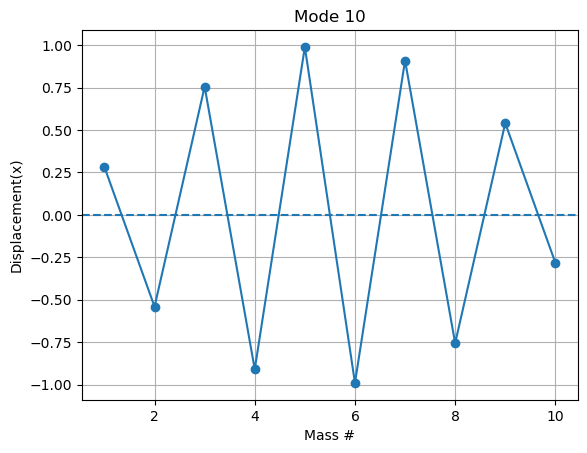

In [30]:
# Problem 1 (b)
import numpy as np
import matplotlib.pyplot as plt

N = 10
masses = np.arange(1, N+1)

mode_number = 10
mode_shape = np.sin(mode_number*np.pi*masses/(N+1))

plt.figure()
plt.plot(masses, mode_shape, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Mass #")
plt.ylabel("Displacement(x)")
plt.title("Mode 10")
plt.grid(True)
plt.show()

In [26]:
# Problem 2(a)
import numpy as np

A = np.array([[10, 2, 0],
      [-2, 8, -4],
      [0, -4, 6]], dtype=float)

b = np.array([12, 0, -5], dtype=float)

x = np.linalg.solve(A,b)
print(x)

[ 1.23255814 -0.1627907  -0.94186047]


In [4]:
# Problem 2(b)
import numpy as np

theta_1 = np.radians(30)
theta_2 = np.radians(45)
W = 1

A = np.array([[-np.cos(theta_1), np.cos(theta_2)],
              [np.sin(theta_1), np.sin(theta_2)]], dtype=float)

b = np.array([0,W], dtype=float)

x = np.linalg.solve(A, b)
print(x)

[0.73205081 0.89657547]


Potential Energy V(x) = 0.25*B*x**4 + 0.5*a*x**2
Force F(x)= -1.0*B*x**3 - 1.0*a*x
Force with constants = -0.5*x**3 - 1.0*x


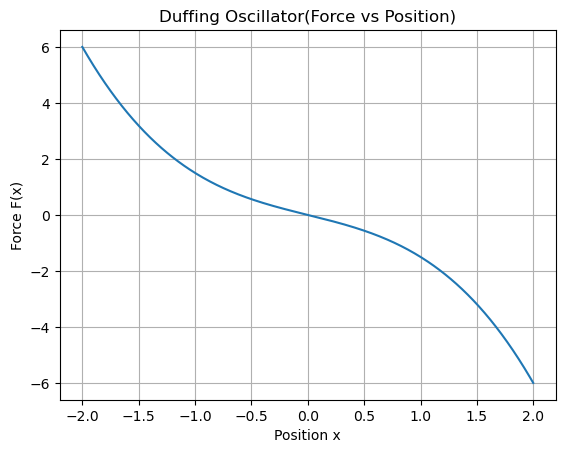

In [10]:
# Problem 3
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x, a, B = sp.symbols('x a B') # a = alpha, B = beta

V = (1/2)*a*x**2 + (1/4)*B*x**4
force_expr = -sp.diff(V,x)

print("Potential Energy V(x) =", V)
print("Force F(x)=", force_expr)

a_val = 1
B_val = 0.5 # applying values to alpha and B
force_with_constants = force_expr.subs({a: a_val, B: B_val})

print("Force with constants =", force_with_constants)

#Numpy function
force_function = sp.lambdify(x, force_with_constants, 'numpy')
# Plotting values (-x=2 to x=2)
x_val = np.linspace(-2,2,400)
force_val = force_function(x_val)

plt.plot(x_val, force_val)
plt.xlabel('Position x')
plt.ylabel('Force F(x)')
plt.title('Duffing Oscillator(Force vs Position)')
plt.grid(True)
plt.show()

In [11]:
# Problem 4
import sympy as sp

t, y, w0 = sp.symbols('t y w0') # y = gamma, w0 = omega nought
x = sp.Function('x')

# Making the ODE
ode = sp.Eq(x(t).diff(t,2) + y*x(t).diff(t) + w0**2*x(t),0)
print("ODE:")
print(ode)

# Solving for ODE
general_solution = sp.dsolve(ode, x(t))
print("General Solution")
print(general_solution)

# Overdamping case
overdamped_case = general_solution.subs({y: 5, w0 :2})
print("Overdamped Case (y=5, w0=2)")
print(overdamped_case)

ODE:
Eq(w0**2*x(t) + y*Derivative(x(t), t) + Derivative(x(t), (t, 2)), 0)
General Solution
Eq(x(t), C1*exp(t*(-y + sqrt(-4*w0**2 + y**2))/2) + C2*exp(-t*(y + sqrt(-4*w0**2 + y**2))/2))
Overdamped Case (y=5, w0=2)
Eq(x(t), C1*exp(-t) + C2*exp(-4*t))


Symbolic root function
      ⎛√2⋅√E⋅L⋅√m⎞     _________
√E⋅tan⎜──────────⎟ - ╲╱ -E + v₀ 
      ⎝    h     ⎠              


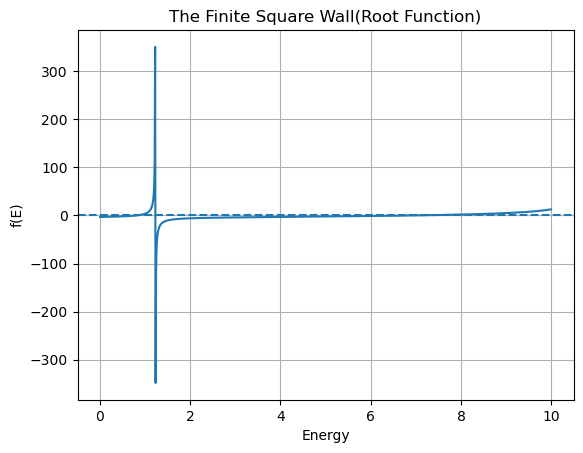

ValueError: f(a) and f(b) must have different signs

In [19]:
# Problem 5 
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

E, m, L, h, v0 = sp.symbols('E m L h v0', positive=True)

# Root function
f_expr = sp.sqrt(E)*sp.tan(sp.sqrt(2*m*L**2*E / h**2)) - sp.sqrt(v0 - E)

print("Symbolic root function")
sp.pprint(f_expr)

# inserting values in for constants
f_num_expr = f_expr.subs({m:1, L: 1, h: 1, v0: 10})
# making function of NumPy
f_num = sp.lambdify(E, f_num_expr, 'numpy')

# Plotting
E_val = np.linspace(0.01, 9.99, 1000)
f_val = f_num(E_val)

plt.plot(E_val, f_val)
plt.axhline(0, linestyle='--')
plt.xlabel('Energy')
plt.ylabel('f(E)')
plt.title('The Finite Square Wall(Root Function)')
plt.grid(True)
plt.show()

# Finding Ground State
sol = root_scalar(f_num, bracket=[0.5, 1.5], method='brentq')

print("Exact energy of Ground State =", sol.root)